# EDA — Telco Customer Churn

Разведочный анализ данных: распределения, пропуски, связь признаков с целевой переменной.

In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Загрузка данных

In [10]:
df = pd.read_csv('../data/telco_churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Качество данных

In [ ]:
print('Дубликаты:', df.duplicated().sum())
print()
print('Типы и пропуски:')
print(df.dtypes)
print()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Пропуски после конвертации TotalCharges:', df['TotalCharges'].isna().sum())

Дубликаты: 0

Типы и пропуски:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Пропуски после конвертации TotalCharges: 11


## 3. Целевая переменная — баланс классов

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Доля оттока: 26.5%


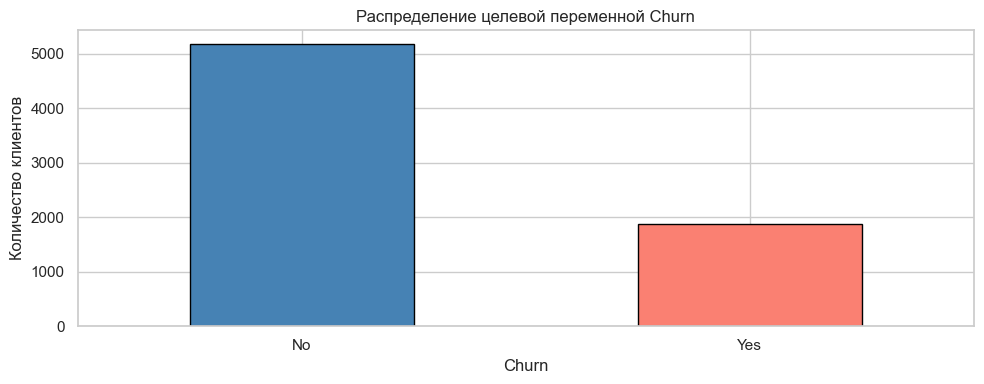

In [12]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f'Доля оттока: {churn_counts["Yes"] / len(df):.1%}')

churn_counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Распределение целевой переменной Churn')
plt.xlabel('Churn')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Числовые признаки

In [13]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df[num_cols].describe().round(2))

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80


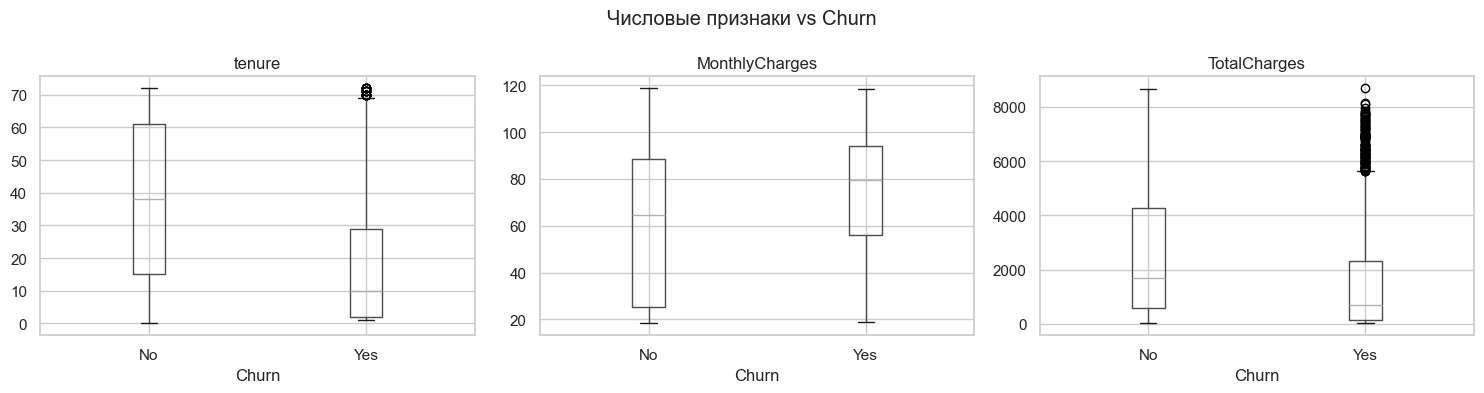

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Churn')
plt.suptitle('Числовые признаки vs Churn')
plt.tight_layout()
plt.show()

## 5. Категориальные признаки — отток по группам

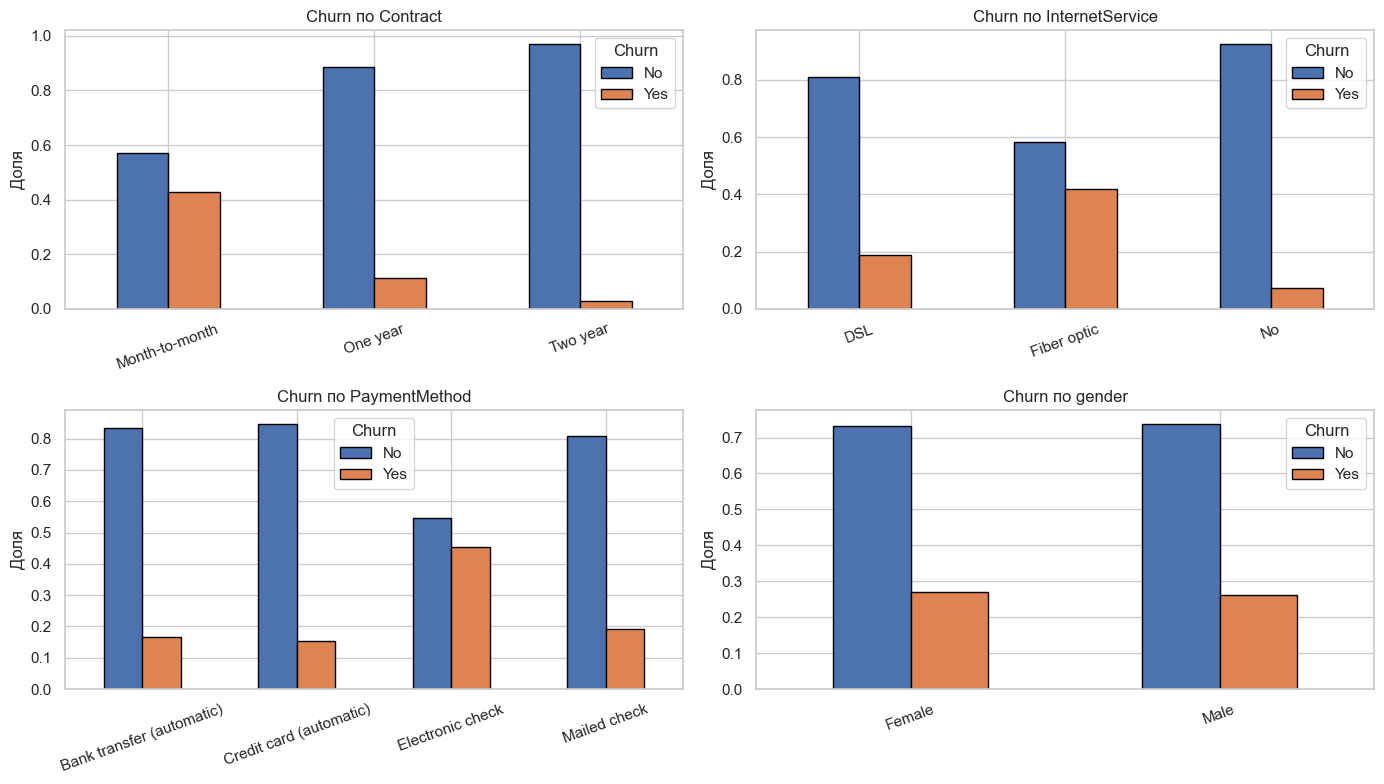

In [15]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = df.groupby(col)['Churn'].value_counts(normalize=True).unstack().fillna(0)
    ct.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(f'Churn по {col}')
    ax.set_ylabel('Доля')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 6. Корреляционная матрица числовых признаков

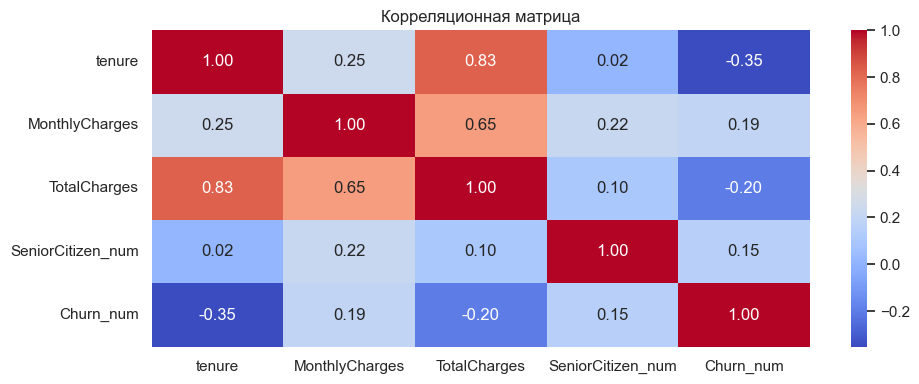

In [16]:
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)
df['SeniorCitizen_num'] = df['SeniorCitizen']
corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen_num', 'Churn_num']]
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

## 7. Итог

Датасет чистый — дубликатов нет, пропуски только в TotalCharges (11 штук), заполнил медианой. Дисбаланс классов умеренный (~26% уходят), ничего специального с ним делать не стал.

Самое очевидное из графиков: клиенты с месячным контрактом уходят сильно чаще чем с годовым или двухлетним. Также чем меньше стаж — тем выше вероятность ухода. MonthlyCharges у уходящих клиентов в среднем выше.

TotalCharges сильно коррелирует с tenure — что логично, это просто накопленная сумма. Для RandomForest это не критично.